In [2]:
import sys
import os

sys.path.append(os.path.abspath("../src"))

import pandas as pd
import numpy as np
from composition_features import expand_compositions
from alloy_descriptors import compute_alloy_descriptors
from alloy_descriptors import VEC  # import the dictionary
from temperature_features import add_temperature_features
df = pd.read_csv("../data/processed/master_hea_data.csv")
df.head()

,T_e,Volume,E_F,N_Ef,gamma,C_e,v_F,tau_e,k_e,k_lat,lambda,Log10_Ge,Composition
0,100,59.60,28.981,0.929,0.567,8.015758,2.396,16.113,0.023210,6.742913,2.2634,-5.751473,AlCrFeCoNi
1,200,59.61,28.982,0.930,0.569,16.026932,2.471,18.603,0.154747,3.361189,0.9802,-9.457885,AlCrFeCoNi
2,300,59.63,28.983,0.931,0.568,24.030523,2.573,16.346,0.285066,2.245305,0.7437,-13.033218,AlCrFeCoNi
3,400,59.66,28.983,0.931,0.566,32.026321,2.541,13.579,0.335095,1.690344,0.6714,-16.600629,AlCrFeCoNi
4,500,59.68,28.983,0.931,0.565,40.014133,2.534,11.182,0.350883,1.357377,0.6523,-20.154063,AlCrFeCoNi


In [ ]:
df_expanded = expand_compositions(df)
df_expanded.head()



In [ ]:
df_expanded[df["Composition"] == "Co-0.05_Xx3-0.95"].head()


In [ ]:
df_expanded[df["Composition"] == "AlCrFeCoNi"].head()


In [ ]:
df_expanded.to_csv("../data/processed/hea_ml_ready.csv", index=False)

In [ ]:
df = pd.read_csv("../data/processed/master_hea_data.csv")
df = expand_compositions(df)
df.head()


In [ ]:
df.columns
elements = [
    col for col in df.columns
    if col[0].isupper() and len(col) <= 2
]

In [ ]:

elements = [el for el in VEC.keys() if el in df.columns]
df = compute_alloy_descriptors(df, elements)
df[["VEC", "delta", "chi_avg"]].head()

In [ ]:
df[["Al","Cr","Fe","Co","Ni"]].head()

In [3]:
df = add_temperature_features(df)

df[["T_e", "logT", "T_norm", "Ce_over_T", "T_tau", "k_ratio"]].head()

,T_e,logT,T_norm,Ce_over_T,T_tau,k_ratio
0,100,2.000000,100,0.080158,1611.3,0.003442
1,200,2.301030,200,0.080135,3720.6,0.046039
2,300,2.477121,300,0.080102,4903.8,0.126961
3,400,2.602060,400,0.080066,5431.6,0.198241
4,500,2.698970,500,0.080028,5591.0,0.258501


<Axes: xlabel='T_e'>

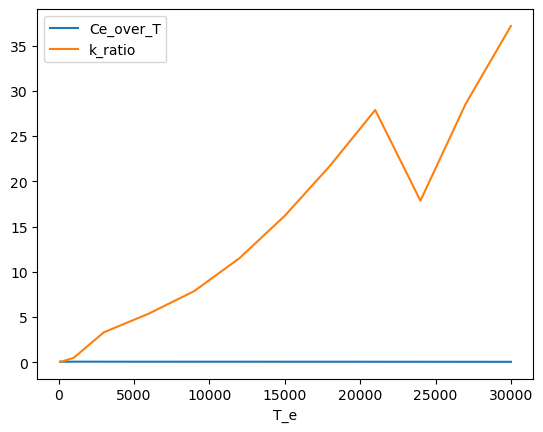

In [4]:
df[df["Composition"]=="Co-0.05_Xx3-0.95"].plot(
    x="T_e", y=["Ce_over_T", "k_ratio"]
)

In [1]:
import sys
import os
import pandas as pd

# Add src folder to path so we can import our custom modules
sys.path.append(os.path.abspath("../src"))

from composition_features import expand_compositions
from alloy_descriptors import compute_alloy_descriptors


In [2]:
RAW_FILE = "../data/processed/master_hea_data.csv"
OUTPUT_FILE = "../data/processed/master_hea_features.csv"

# Load master dataset
df = pd.read_csv(RAW_FILE)
print("Loaded master_hea_data.csv")
df.head()


Loaded master_hea_data.csv


,T_e,Volume,E_F,N_Ef,gamma,C_e,v_F,tau_e,k_e,k_lat,lambda,Log10_Ge,Composition
0,100,59.60,28.981,0.929,0.567,8.015758,2.396,16.113,0.023210,6.742913,2.2634,-5.751473,AlCrFeCoNi
1,200,59.61,28.982,0.930,0.569,16.026932,2.471,18.603,0.154747,3.361189,0.9802,-9.457885,AlCrFeCoNi
2,300,59.63,28.983,0.931,0.568,24.030523,2.573,16.346,0.285066,2.245305,0.7437,-13.033218,AlCrFeCoNi
3,400,59.66,28.983,0.931,0.566,32.026321,2.541,13.579,0.335095,1.690344,0.6714,-16.600629,AlCrFeCoNi
4,500,59.68,28.983,0.931,0.565,40.014133,2.534,11.182,0.350883,1.357377,0.6523,-20.154063,AlCrFeCoNi


In [5]:
# Convert composition strings into fraction columns
df = expand_compositions(df)
print("Expanded compositions")
df.head()


Expanded compositions


,T_e,Volume,E_F,N_Ef,gamma,C_e,v_F,tau_e,k_e,k_lat,lambda,Log10_Ge,Composition,Al,Cr,Fe,Co,Ni,Mn,Cu
0,100,59.60,28.981,0.929,0.567,8.015758,2.396,16.113,0.023210,6.742913,2.2634,-5.751473,AlCrFeCoNi,0.2,0.2,0.2,0.2,0.2,0.0,0.0
1,200,59.61,28.982,0.930,0.569,16.026932,2.471,18.603,0.154747,3.361189,0.9802,-9.457885,AlCrFeCoNi,0.2,0.2,0.2,0.2,0.2,0.0,0.0
2,300,59.63,28.983,0.931,0.568,24.030523,2.573,16.346,0.285066,2.245305,0.7437,-13.033218,AlCrFeCoNi,0.2,0.2,0.2,0.2,0.2,0.0,0.0
3,400,59.66,28.983,0.931,0.566,32.026321,2.541,13.579,0.335095,1.690344,0.6714,-16.600629,AlCrFeCoNi,0.2,0.2,0.2,0.2,0.2,0.0,0.0
4,500,59.68,28.983,0.931,0.565,40.014133,2.534,11.182,0.350883,1.357377,0.6523,-20.154063,AlCrFeCoNi,0.2,0.2,0.2,0.2,0.2,0.0,0.0
